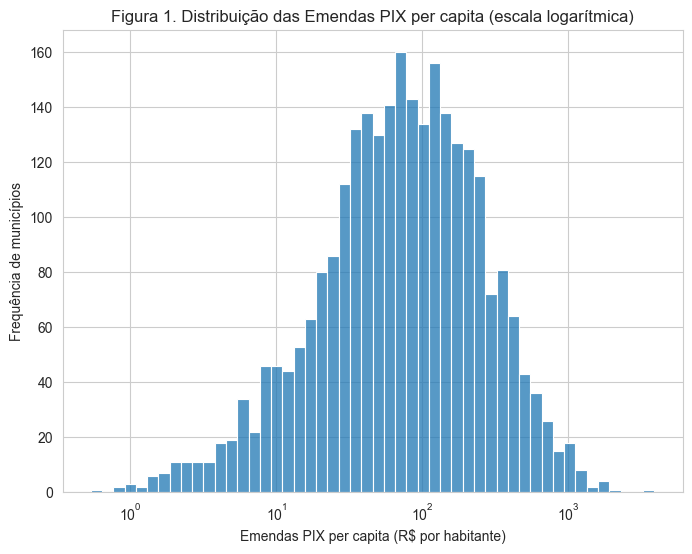

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo para os gráficos
sns.set_style("whitegrid")

# Carregar a base de dados unificada
df = pd.read_csv('../data/dados_unificados_prefeitos_200k.csv')

# Histograma do valor per capita das Emendas PIX (escala logarítmica no eixo x)
plt.figure(figsize=(8,6))
sns.histplot(df['emendas_pix_per_capita_partido_prefeito_eleito'], bins=50, log_scale=(True, False))
plt.xlabel('Emendas PIX per capita (R$ por habitante)')
plt.ylabel('Frequência de municípios')
plt.title('Figura 1. Distribuição das Emendas PIX per capita (escala logarítmica)')
plt.show()

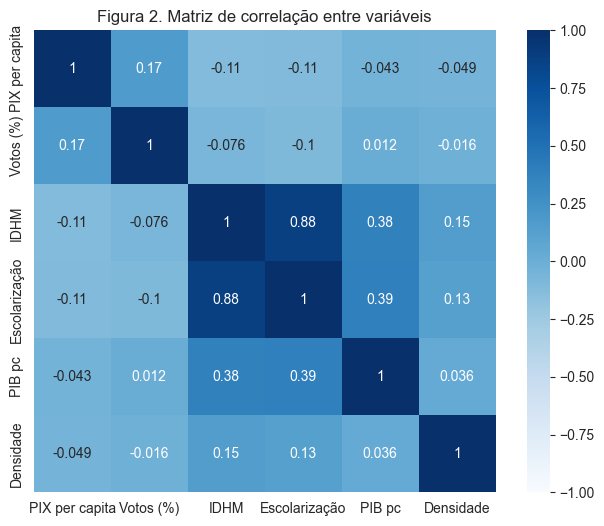

In [4]:
# Selecionar colunas numéricas relevantes para a correlação
cols = ['emendas_pix_per_capita_partido_prefeito_eleito',
        'porcentagem_votos_validos_2024',
        'idhm_2010','alfabetizacao_2010',
        'pib_per_capita_2021','densidade_demografica_2010']
corr = df[cols].corr()

# Configurar labels curtos para melhor visualização no gráfico
labels = ['PIX per capita','Votos (%)','IDHM','Escolarização','PIB pc','Densidade']

# Mapa de calor da matriz de correlação
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels, vmin=-1, vmax=1, square=True)
plt.title('Figura 2. Matriz de correlação entre variáveis')
plt.show()


C:\Users\bruno\AppData\Local\Temp\ipykernel_12372\839847676.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_plot['emendas_pix_per_capita_partido_prefeito_eleito'].replace(0, 1, inplace=True)


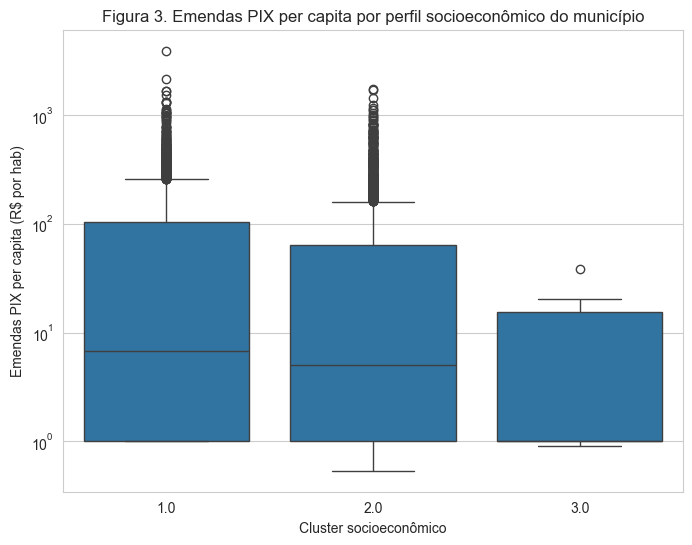

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Definir variáveis para clusterização e padronizá-las
vars_cluster = ['idhm_2010','alfabetizacao_2010','pib_per_capita_2021','densidade_demografica_2010']
df_cluster = df.dropna(subset=vars_cluster).copy()
X = StandardScaler().fit_transform(df_cluster[vars_cluster])

# Aplicar k-means com 3 clusters socioeconômicos
kmeans = KMeans(n_clusters=3, random_state=0)
df_cluster['cluster'] = kmeans.fit_predict(X)

# Opcional: renumerar clusters em ordem de desenvolvimento (1=baixo dev, 3=alto dev)
cluster_idhm = df_cluster.groupby('cluster')['idhm_2010'].mean().sort_values()
cluster_map = {old_label: idx+1 for idx, old_label in enumerate(cluster_idhm.index)}
df_cluster['cluster'] = df_cluster['cluster'].map(cluster_map)

# Atribuir rótulos de cluster de volta ao dataframe principal
df = df.merge(df_cluster[['municipio','cluster']], on='municipio', how='left')

# Preparar dados para boxplot (substituir zero por 1 para permitir escala log no eixo Y)
df_plot = df.copy()
df_plot['emendas_pix_per_capita_partido_prefeito_eleito'].replace(0, 1, inplace=True)

# Boxplot das Emendas PIX per capita por cluster socioeconômico (eixo Y em escala log)
plt.figure(figsize=(8,6))
sns.boxplot(data=df_plot, x='cluster', y='emendas_pix_per_capita_partido_prefeito_eleito', showfliers=True)
plt.yscale('log')
plt.xlabel('Cluster socioeconômico')
plt.ylabel('Emendas PIX per capita (R$ por hab)')
plt.title('Figura 3. Emendas PIX per capita por perfil socioeconômico do município')
plt.show()


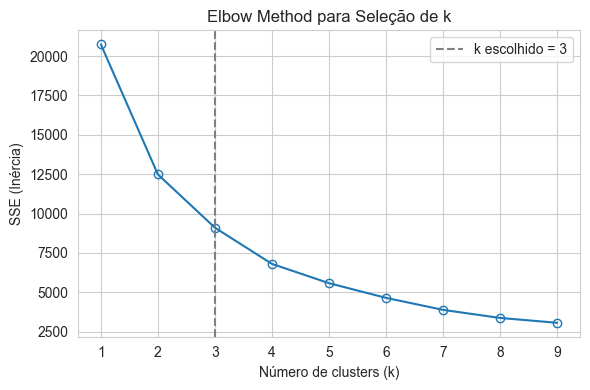

C:\Users\bruno\AppData\Local\Temp\ipykernel_12372\4196538717.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Cluster', y='emendas_pix_per_capita_partido_prefeito_eleito', palette='Set2')


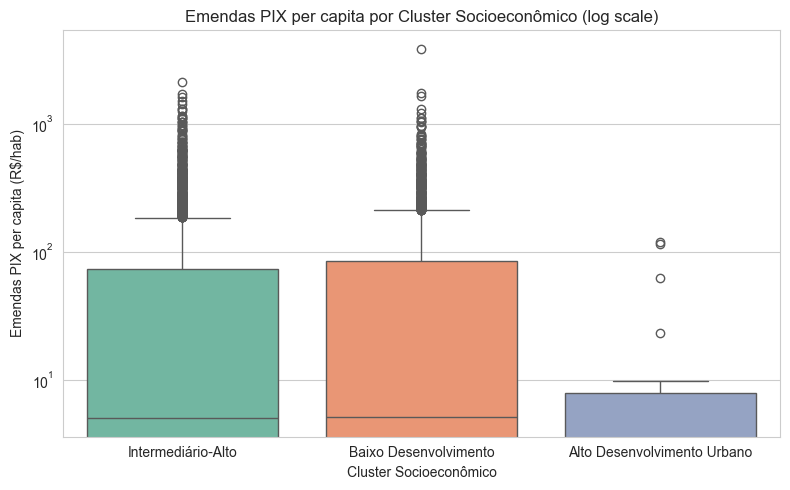

,idhm_2010,pib_per_capita_2021,densidade_demografica_2010,alfabetizacao_2010,cluster,cluster_label
0,0.708,18491.217064,133.397997,92.19,0,Intermediário-Alto
1,0.689,28184.630102,7.127400,90.88,0,Intermediário-Alto
2,0.689,25842.850511,16.509351,89.16,0,Intermediário-Alto
3,0.698,23869.415656,12.479830,91.28,0,Intermediário-Alto
4,0.628,12322.938529,98.228786,86.29,1,Baixo Desenvolvimento


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Carregar dados
df = pd.read_csv('../data/dados_unificados_prefeitos_200k.csv')

# Selecionar features
features = df[['idhm_2010', 'pib_per_capita_2021', 'densidade_demografica_2010', 'alfabetizacao_2010']].dropna().reset_index(drop=True)

# Padronizar (z-score)
scaler = StandardScaler()
X = scaler.fit_transform(features)

# Método do cotovelo para SSE
sse = []
ks = range(1, 10)
for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

# Determinar k ótimo: aqui escolhemos k=3 como ponto de inflexão prático
optimal_k = 3

# Plot curva de cotovelo
plt.figure(figsize=(6, 4))
plt.plot(ks, sse, 'o-', markerfacecolor='none')
plt.axvline(optimal_k, linestyle='--', color='gray', label=f'k escolhido = {optimal_k}')
plt.xlabel('Número de clusters (k)')
plt.ylabel('SSE (Inércia)')
plt.title('Elbow Method para Seleção de k')
plt.legend()
plt.tight_layout()
plt.show()

# Ajustar KMeans com k ótimo
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)
features['cluster'] = clusters

# Mapear clusters em ordem de desenvolvimento
centroid_means = kmeans.cluster_centers_.mean(axis=1)
order = centroid_means.argsort()
mapping = {
    order[0]: 'Baixo Desenvolvimento',
    order[1]: 'Intermediário-Alto',
    order[2]: 'Alto Desenvolvimento Urbano'
}
features['cluster_label'] = features['cluster'].map(mapping)

# Boxplot das Emendas PIX por cluster (log scale)
df_plot = df.loc[features.index].copy()
df_plot['Cluster'] = features['cluster_label']
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_plot, x='Cluster', y='emendas_pix_per_capita_partido_prefeito_eleito', palette='Set2')
plt.yscale('log')
plt.xlabel('Cluster Socioeconômico')
plt.ylabel('Emendas PIX per capita (R$/hab)')
plt.title('Emendas PIX per capita por Cluster Socioeconômico (log scale)')
plt.tight_layout()
plt.show()

# Exibir primeiras linhas com cluster
features.head()
